In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langchain_community langchain_anthropic langchain_experimental faiss-cpu tiktoken pypdf langchain openai langchain_anthropic langchain_experimental

In [100]:
# Importación de librerias
# LangGraph
from langgraph.graph import START, END, StateGraph
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

# LangChain
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools.retriever import create_retriever_tool
from langchain.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage

# Utilidades
from typing import TypedDict, Optional, Dict, List, Literal, Annotated
from dotenv import load_dotenv, find_dotenv
import tiktoken
from IPython.display import Image, display


In [101]:
# Carga de variables de entorno
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)


True

In [102]:
def count_tokens_in_docs(docs, model_name="gpt-4o"):
    """
    Calcula la cantidad total de tokens para una lista de documentos
    usando la librería tiktoken.

    :param docs: Lista de documentos (por ejemplo, la salida de un loader PDF).
    :param model_name: Nombre del modelo para el que queremos simular el conteo.
    :return: Número total de tokens en el contenido de los documentos.
    """
    # Obtenemos la codificación que usa el modelo seleccionado
    encoding = tiktoken.encoding_for_model(model_name)

    total_tokens = 0
    for doc in docs:
        # doc.page_content es el texto de cada página/documento
        text = doc.page_content
        total_tokens += len(encoding.encode(text))

    return total_tokens

In [103]:
# 2. CARGA DEL PDF
# ----------------------------------------------------------------------------
file_path = "carga.pdf"
loader = PyPDFLoader(file_path)
docs = loader.load()

In [104]:
# Cantidad de documentos extraídos (páginas, secciones, etc. según PyPDFLoader)
print("Número de docs cargados:", len(docs))

# Opcional: vista previa de los primeros 100 caracteres de la primera página
print("Preview contenido:", docs[0].page_content[0:100])
print("Metadata:", docs[0].metadata)

Número de docs cargados: 4
Preview contenido: Carga de datos 
 
Este proceso permite agregar en la liquidación de sueldos del trabajador, valores 
Metadata: {'producer': 'Microsoft® Word para Microsoft 365', 'creator': 'Microsoft® Word para Microsoft 365', 'creationdate': '2022-08-29T22:01:31-04:00', 'author': 'Juan Carlos Rojas Banda', 'moddate': '2022-08-29T22:01:31-04:00', 'source': 'carga.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}


In [105]:
# 3. CONTAR TOKENS ANTES DE HACER NADA
# ----------------------------------------------------------------------------
tokens_en_documento = count_tokens_in_docs(docs, model_name="gpt-4o")
print("Tokens en el documento completo:", tokens_en_documento)

Tokens en el documento completo: 854


In [106]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)
splits = text_splitter.split_documents(docs)


In [107]:
# Crea los embeddings
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(splits, embeddings)

# Crea el retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [108]:
# Modelo utilizado
llm = ChatOpenAI(model="gpt-4o")

In [109]:
# Creación del estado
class GlobalState(TypedDict): # Estado Globa
    graph: str
    messages: list[dict] # Es una lista de diccionarios
    next: str
    
class SearchState(TypedDict):
    search: List[dict]

In [110]:
# Miembros del equipo
members = ["researcher", "retriever", "amparo", "buker"]
options = members + ["FINISH"]

In [111]:
# Router con opciones para el llm
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["researcher", "retriever","amparo", "buker",  "FINISH"]

In [112]:
# Definir un nodo info o agent principal
system_prompt_amparo = "Eres Amparo un asistente virtual creado para apoyar al depto de rrhh de la empresa consstructora del mar. Tu trabajo consiste en responder a las solicitudes de los usuarios"
info_agent = create_react_agent(
    llm,
    tools=[],
    prompt=ChatPromptTemplate.from_messages([
        ("system", system_prompt_amparo),
        ("human", "{messages}")
    ])
)

def amparo(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = info_agent.invoke(state)
    print("RESPUESTA DE AMPARO: \n")
    print(result["messages"])
    return Command(
        goto="supervisor",
        update={"messages": result["messages"]}
    )

In [113]:
# Tool de search node 
tavily_tool = TavilySearchResults(max_results=1)
research_agent = create_react_agent(
    llm, tools=[tavily_tool], prompt="Eres un agente especializado en busqueda web."
)

In [114]:
def search_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = research_agent.invoke(state)
    # print("DEBUG result: ", result)  # <-- esto

    return Command(goto="supervisor", 
                   update = {
                       "__state__": {"search":result["messages"]},"messages":result["messages"]})

In [115]:
# Crea una herramienta a partir del retriever
retriever_tool = create_retriever_tool(
    retriever,
    name="reglamento_retriever",
    description="Busca información manual de Unyrem de Unysoft."
)

In [116]:
# Crea el agente con la herramienta
retriever_agent = create_react_agent(
    llm,
    tools=[retriever_tool],
    prompt="Eres un agente experto en responder preguntas sobre el manual de carga de datos al módulo UnyRem del sistema Unysoft,"
)

In [117]:
def retriever_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = retriever_agent.invoke(state)
    return Command(
        goto="supervisor",
        update={
            "messages": result["messages"]
        }
    )

In [124]:
# Agente para Buk
def buker_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = retriever_agent.invoke(state)
    return Command( goto="supervisor", update={"messages":result["messages"]})

In [125]:
system_prompt = (
    "Tu nombre es Amparo, un asistente virtual que apoya las gestiones en el área de Recursos Humanos "
    "de la empresa Constructora del Mar II. Tu función principal es gestionar las solicitudes del usuario "
    f"derivándolas a los siguientes agentes especializados: {members}.\n\n"
    
    "El agente especializado 'researcher' se encarga de realizar búsquedas de información en la web.\n"
    "El agente especializado 'retriever' se encarga de recuperar información desde un documento llamado 'Carga de Datos'. "
    "El agente especializado 'buker' se encarga de ayudar al usuario con respecto al uso de la aplicación Buk "
    "Este documento contiene instrucciones sobre cómo cargar información en el módulo UnyRem del ERP Unysoft.\n\n"
    
    "Tu tarea es analizar la pregunta del usuario y decidir cuál agente debe actuar en función de la solicitud.\n"
    "Si la solicitud es general o informal, selecciona el agente más apropiado para responder o investigar.\n"
    "Responde 'FINISH' el miembro a quien designaste la tarea ya la finalizó.\n\n"
    
    "Devuelve **únicamente** el nombre del trabajador a activar (por ejemplo: retriever), o 'FINISH' si todo ha concluido."
)

In [126]:
def supervisor_node(state: GlobalState) -> Command[Literal["researcher", "retriever","amparo", "buker", "__end__"]]:
    print("Este es el mensaje que recibe el supervisor: \n")
    print(state["messages"])
    ultimo_ai = next((msg for msg in reversed(state["messages"]) if isinstance(msg, AIMessage)), None)
    print("ULTIMO AI: ", ultimo_ai)
    # if ultimo_ai:
    if isinstance(state["messages"][-1], AIMessage):
        # ultimo_ai= ultimo_ai.content
        # ultimo_ai= list(ultimo_ai)
        # messages = [{"role":"system", "content":system_prompt},] + ultimo_ai
        goto = "FINISH"
    else:
        messages = [{"role":"system", "content":system_prompt},] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
    print("DIRIGIENDO FLUJO A: ", goto)
    if goto == "FINISH":
        goto = END
    
    return Command(goto=goto, update = {"next":goto})

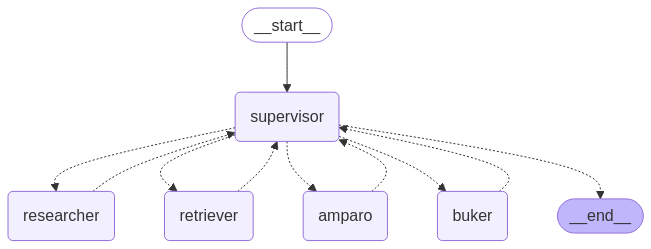

In [127]:
builder = StateGraph(GlobalState)
builder.add_edge(START, "supervisor")
builder.add_node("amparo", amparo)
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher",search_node)
builder.add_node("retriever",retriever_node)
builder.add_node("buker", buker_node)

graph =  builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [121]:
sal = graph.invoke({"messages": ["¿Quien eres y cuales son tus funciones?"]})
for m in sal["messages"]:
    m.pretty_print()


Este es el mensaje que recibe el supervisor: 

['¿Quien eres y cuales son tus funciones?']
ULTIMO AI:  None
DIRIGIENDO FLUJO A:  amparo
RESPUESTA DE AMPARO: 

[HumanMessage(content='¿Quien eres y cuales son tus funciones?', additional_kwargs={}, response_metadata={}, id='61ddf55a-58ea-4b51-a4d3-40a1a05d56dc'), AIMessage(content='Hola, soy Amparo, el asistente virtual del departamento de recursos humanos de la empresa Constructora del Mar. Mi función es ayudar a los empleados y usuarios con sus consultas relacionadas con recursos humanos, como preguntas sobre políticas de la empresa, beneficios, procedimientos, soporte en procesos de selección y reclutamiento, así como otras solicitudes administrativas que puedas tener. Estoy aquí para facilitarte la información que necesites de manera rápida y eficiente. ¿En qué puedo ayudarte hoy?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 97, 'total_tokens': 192, 'completion_tok